In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

In [ ]:
#LA In Progress

In [2]:
import pandas as pd

# Load both files
clinical_preview = pd.read_csv(r"C:\Users\micha\OneDrive\Documents\Thesis_data\Metadata.csv")
prs_preview = pd.read_csv(r"C:\Users\micha\OneDrive\Documents\Thesis_data\LA\stroke_prs_results.best", sep=r"\s+")

print("--- METADATA 'Barcode' Column Samples ---")
print(clinical_preview['Barcode'].head().tolist())

print("\n--- PRSice '.best' File ID Columns ---")
# PRSice usually has FID (Family ID) and IID (Individual ID)
print(prs_preview[['FID', 'IID']].head())

--- METADATA 'Barcode' Column Samples ---
[56002212082587, 56002212084203, 56002212083478, 56002411150838, 56002212082196]

--- PRSice '.best' File ID Columns ---
                            FID                           IID
0  56002212082196.CEL_call_code  56002212082196.CEL_call_code
1  56002212082208.CEL_call_code  56002212082208.CEL_call_code
2  56002212082219.CEL_call_code  56002212082219.CEL_call_code
3  56002212082404.CEL_call_code  56002212082404.CEL_call_code
4  56002212082531.CEL_call_code  56002212082531.CEL_call_code


In [3]:
import pandas as pd

# 1. Load your clinical metadata file
clinical = pd.read_csv(r"C:\Users\micha\OneDrive\Documents\Thesis_data\Metadata.csv")

# 2. Load the PRSice output (.best) file 
prs_output = pd.read_csv(r"C:\Users\micha\OneDrive\Documents\Thesis_data\LA\stroke_prs_results.best", sep=r"\s+")

# FIX 1: Convert Barcode to string and strip spaces
clinical['Barcode'] = clinical['Barcode'].astype(str).str.strip()

# FIX 2: Strip the '.CEL_call_code' suffix from the genomic IDs
# This splits the text at '.' and takes the numeric part before it
prs_output['clean_ID'] = prs_output['IID'].astype(str).str.split('.').str[0].str.strip()

# 3. Merge them using 'Barcode' from your CSV and our new 'clean_ID' from PRSice
merged_data = pd.merge(clinical, prs_output, left_on="Barcode", right_on="clean_ID")

# 4. Clean up and map your exact columns to what the notebook expects
final_df = pd.DataFrame({
    'patient_id':   merged_data['Barcode'],
    'age':          merged_data['Age'],
    'sex':          merged_data['Gender'],       # 0 for male, 1 for female
    'hypertension': merged_data['Hypertension'], # 0 for absent, 1 for present
    'PRS_raw':      merged_data['PRS'],          # Raw PRS score from PRSice
    'sample_type':         merged_data['Group']         # 1 for stroke case, 0 for control
})

# 5. Save a copy as a CSV file to your AA folder for your records
final_df.to_csv(r"C:\Users\micha\OneDrive\Documents\Thesis_data\LA\combined_patient_data.csv", index=False)

# 6. Assign it to the 'data' variable for the rest of the notebook
data = final_df

print("=== Successfully merged data inside Python! ===")
print(f"Total matching patients found: {len(data)}")
print(data.head())

=== Successfully merged data inside Python! ===
Total matching patients found: 10
       patient_id  age     sex hypertension   PRS_raw sample_type
0  56002212082587   30    Male           No -0.009428        Case
1  56002212084203   31  Female          Yes -0.010067        Case
2  56002212083478   40  Female          Yes -0.009556        Case
3  56002411150838   39  Female          Yes -0.013781        Case
4  56002212082196   30  Female           No -0.013040     Control


In [4]:
import pandas as pd

# Set the filepath to your African American clean dataset
filepath = r"C:\Users\micha\OneDrive\Documents\Thesis_data\LA\combined_patient_data.csv"

# Load the data using standard pandas read_csv
data = pd.read_csv(filepath)

# Show a quick summary of the data structure
print("=== Successfully Loaded The Cohort ===")
print(f"Total Rows (Patients): {data.shape[0]}")
print(f"Total Columns: {data.shape[1]}\n")
print("First few rows of your thesis dataset:")
print(data.head())

=== Successfully Loaded The Cohort ===
Total Rows (Patients): 10
Total Columns: 6

First few rows of your thesis dataset:
       patient_id  age     sex hypertension   PRS_raw sample_type
0  56002212082587   30    Male           No -0.009428        Case
1  56002212084203   31  Female          Yes -0.010067        Case
2  56002212083478   40  Female          Yes -0.009556        Case
3  56002411150838   39  Female          Yes -0.013781        Case
4  56002212082196   30  Female           No -0.013040     Control


In [2]:
import pandas as pd

# 1. Load the dataset
filepath = r"C:\Users\micha\OneDrive\Documents\Thesis_data\LA\combined_patient_data.csv"
data = pd.read_csv(filepath)

# 2. Encode 'sex' (Male = 0, Female = 1)
data['sex'] = data['sex'].map({'Male': 0, 'Female': 1})

# 3. Encode 'hypertension' (No = 0, Yes = 1)
data['hypertension'] = data['hypertension'].map({'No': 0, 'Yes': 1})

# 4. Rename 'sample_type' to 'case' and encode it (Control = 0, Case = 1)
data = data.rename(columns={'sample_type': 'case'})
data['case'] = data['case'].map({'Control': 0, 'Case': 1})

# 5. Verify the conversion
print("=== Encoded The Cohort ===")
print(f"Total Rows (Patients): {data.shape[0]}")
print(f"Total Columns: {data.shape[1]}\n")
print("First few rows of your numeric thesis dataset:")
print(data[['patient_id', 'age', 'sex', 'hypertension', 'PRS_raw', 'case']].head())

=== Encoded The Cohort ===
Total Rows (Patients): 10
Total Columns: 6

First few rows of your numeric thesis dataset:
     patient_id  age  sex  hypertension   PRS_raw  case
0  5.600000e+13   30    0             0 -0.009428     1
1  5.600000e+13   31    1             1 -0.010067     1
2  5.600000e+13   40    1             0 -0.009556     1
3  5.600000e+13   39    1             0 -0.013781     1
4  5.600000e+13   30    1             0 -0.013040     0


In [3]:
# ── Step 2: Standardise PRS ───────────────────────────────────────────────
# StandardScaler converts raw PRS values so that:
#   mean of the whole column becomes 0
#   one unit = one standard deviation
#
# Formula for each value:
#   PRS_std = (PRS_raw - mean of all PRS_raw) / std of all PRS_raw
#
# Example for P001:
#   mean of PRS_raw column = 0.556
#   std  of PRS_raw column = 0.626
#   P001 PRS_std = (0.82 - 0.556) / 0.626 = +0.422
#   This means P001 sits 0.42 standard deviations above the group average

scaler          = StandardScaler()
data['PRS_std'] = scaler.fit_transform(data[['PRS_raw']]).flatten()

# Show the before and after side by side
print("=== PRS standardisation: before and after ===")
print(data[['patient_id', 'PRS_raw', 'PRS_std']].to_string(index=False))
print(f"\nPRS_raw  — mean: {data['PRS_raw'].mean():.3f}  std: {data['PRS_raw'].std():.3f}")
print(f"PRS_std  — mean: {data['PRS_std'].mean():.3f}  std: {data['PRS_std'].std(ddof=0):.3f}")

=== PRS standardisation: before and after ===
  patient_id   PRS_raw   PRS_std
5.600000e+13 -0.009428  1.137203
5.600000e+13 -0.010067  0.708382
5.600000e+13 -0.009556  1.051257
5.600000e+13 -0.013781 -1.783859
5.600000e+13 -0.013040 -1.286273
5.600000e+13 -0.011085  0.025808
5.600000e+13 -0.010494  0.421791
5.600000e+13 -0.010373  0.503522
5.600000e+13 -0.010400  0.485313
5.600000e+13 -0.013005 -1.263145

PRS_raw  — mean: -0.011  std: 0.002
PRS_std  — mean: -0.000  std: 1.000


In [4]:
# ── Step 3: Run the two models ────────────────────────────────────────────
y = data['case'].values

# Model A: clinical factors only
X_A     = data[['age', 'sex', 'hypertension']].values
model_A = LogisticRegression()
model_A.fit(X_A, y)
prob_A  = model_A.predict_proba(X_A)[:,1]
auc_A   = roc_auc_score(y, prob_A)

# Model B: clinical + PRS
X_B     = data[['age', 'sex', 'hypertension', 'PRS_std']].values
model_B = LogisticRegression()
model_B.fit(X_B, y)
prob_B  = model_B.predict_proba(X_B)[:,1]
auc_B   = roc_auc_score(y, prob_B)

# ── Step 4: Show predicted probabilities per patient ──────────────────────
data['prob_A'] = prob_A.round(3)   # probability from clinical model
data['prob_B'] = prob_B.round(3)   # probability from clinical + PRS model

print("=== Predicted stroke probability per patient ===")
print(data[['patient_id','age','hypertension','PRS_std','case',
            'prob_A','prob_B']].to_string(index=False))

print(f"\n=== Model performance ===")
print(f"AUC  Model A (clinical only):        {auc_A:.3f}")
print(f"AUC  Model B (clinical + PRS): {auc_B:.3f}")
print(f"Delta AUC:                          +{auc_B - auc_A:.3f}")

=== Predicted stroke probability per patient ===
  patient_id  age  hypertension   PRS_std  case  prob_A  prob_B
5.600000e+13   30             0  1.137203     1   0.432   0.516
5.600000e+13   31             1  0.708382     1   0.601   0.645
5.600000e+13   40             0  1.051257     1   0.402   0.489
5.600000e+13   39             0 -1.783859     1   0.413   0.284
5.600000e+13   30             0 -1.286273     0   0.514   0.410
5.600000e+13   21             0  0.025808     0   0.533   0.525
5.600000e+13   57             0  0.421791     0   0.239   0.269
5.600000e+13   65             0  0.503522     0   0.136   0.156
5.600000e+13   31             0  0.485313     0   0.502   0.542
5.600000e+13   51             0 -1.263145     0   0.228   0.162

=== Model performance ===
AUC  Model A (clinical only):        0.625
AUC  Model B (clinical + PRS): 0.708
Delta AUC:                          +0.083


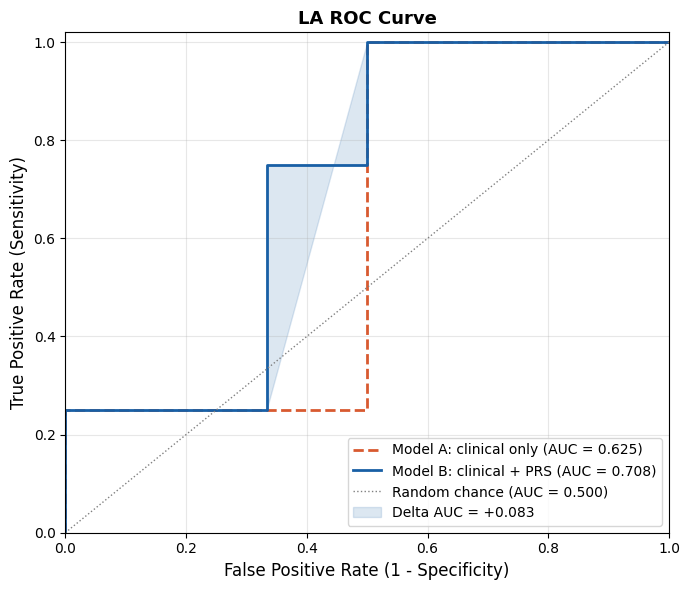

In [5]:
# ── ROC curve ─────────────────────────────────────────────────────────────
from scipy.interpolate import interp1d

fpr_A, tpr_A, _ = roc_curve(y, prob_A)
fpr_B, tpr_B, _ = roc_curve(y, prob_B)

fig, ax = plt.subplots(figsize=(7, 6))

# Plot the primary curves safely
ax.plot(fpr_A, tpr_A, color='#D85A30', linewidth=2, linestyle='--',
        label=f'Model A: clinical only (AUC = {auc_A:.3f})')
ax.plot(fpr_B, tpr_B, color='#185FA5', linewidth=2,
        label=f'Model B: clinical + PRS (AUC = {auc_B:.3f})')
ax.plot([0,1], [0,1], color='gray', linestyle=':', linewidth=1,
        label='Random chance (AUC = 0.500)')

# FIX: Interpolate Model A's sensitivity curve to match Model B's coordinates exactly
tpr_A_interpolated = interp1d(fpr_A, tpr_A, kind='linear')(fpr_B)

# Shade the region between the two matched curves safely
ax.fill_between(fpr_B, tpr_A_interpolated, tpr_B,
                alpha=0.15, color='#185FA5',
                label=f'Delta AUC = +{auc_B - auc_A:.3f}')

ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('LA ROC Curve', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_path = r"C:\Users\micha\OneDrive\Documents\Thesis_data\LA\Stroke_roc_curve.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

=== Distribution Plot saved to: C:\Users\micha\OneDrive\Documents\Thesis_data\LA\prs_distribution.png ===


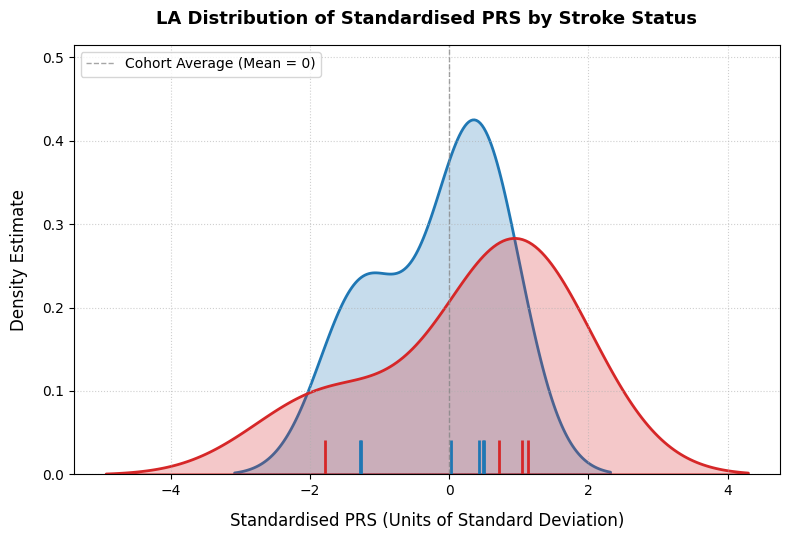

In [6]:
import seaborn as sns

plot_data = data.copy()
plot_data['Diagnosis'] = plot_data['case'].map({0: 'Control', 1: 'Stroke Case'})

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = {'Control': '#1F77B4', 'Stroke Case': '#D62728'}

# Plot density
sns.kdeplot(data=plot_data, x='PRS_std', hue='Diagnosis', fill=True, palette=colors, 
            alpha=0.25, linewidth=2, common_norm=False, ax=ax)

# Plot explicit patient tick marks
sns.rugplot(data=plot_data, x='PRS_std', hue='Diagnosis', palette=colors, 
            height=0.08, linewidth=2, legend=False, ax=ax)

ax.set_title('LA Distribution of Standardised PRS by Stroke Status', fontsize=13, pad=15, fontweight='bold')
ax.set_xlabel('Standardised PRS (Units of Standard Deviation)', fontsize=12, labelpad=10)
ax.set_ylabel('Density Estimate', fontsize=12, labelpad=10)
ax.grid(True, linestyle=':', alpha=0.6)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Cohort Average (Mean = 0)')
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()

# Save image
save_path_dist = r"C:\Users\micha\OneDrive\Documents\Thesis_data\LA\prs_distribution.png"
plt.savefig(save_path_dist, dpi=300, bbox_inches='tight')
print(f"=== Distribution Plot saved to: {save_path_dist} ===")
plt.show()

In [7]:
def delong_roc_test(y_true, preds_A, preds_B):
    """
    Calculates the DeLong Test for comparing two correlated ROC curves.
    """
    y_true = np.array(y_true)
    preds_A = np.array(preds_A)
    preds_B = np.array(preds_B)

    # Separate predictions into cases (stroke) and controls (healthy)
    cases_A = preds_A[y_true == 1]
    controls_A = preds_A[y_true == 0]
    cases_B = preds_B[y_true == 1]
    controls_B = preds_B[y_true == 0]
    
    m = len(cases_A) # Number of cases
    n = len(controls_A) # Number of controls

    # Calculate absolute AUCs
    auc_A = roc_auc_score(y_true, preds_A)
    auc_B = roc_auc_score(y_true, preds_B)

    # 1. Calculate Structural Components for Model A
    V10_A = np.array([sum(case > controls_A) + 0.5 * sum(case == controls_A) for case in cases_A]) / n
    V01_A = np.array([sum(cases_A > control) + 0.5 * sum(cases_A == control) for control in controls_A]) / m
    
    # 2. Calculate Structural Components for Model B
    V10_B = np.array([sum(case > controls_B) + 0.5 * sum(case == controls_B) for case in cases_B]) / n
    V01_B = np.array([sum(cases_B > control) + 0.5 * sum(cases_B == control) for control in controls_B]) / m

    # 3. Calculate Variance for both models
    var_A = (np.var(V10_A, ddof=1) / m) + (np.var(V01_A, ddof=1) / n)
    var_B = (np.var(V10_B, ddof=1) / m) + (np.var(V01_B, ddof=1) / n)
    
    # 4. Calculate Covariance (The overlap in errors)
    cov10 = np.cov(V10_A, V10_B)[0, 1] / m
    cov01 = np.cov(V01_A, V01_B)[0, 1] / n
    cov_AB = cov10 + cov01

    # 5. Calculate Standard Error, Z-Score, and P-Value
    se = np.sqrt(var_A + var_B - 2 * cov_AB)
    z_score = (auc_B - auc_A) / se # Measuring improvement of B over A
    p_value = 2 * (1 - scipy.stats.norm.cdf(abs(z_score)))

    return auc_A, auc_B, z_score, p_value

auc_A_d, auc_B_d, z, p = delong_roc_test(y, prob_A, prob_B)
print(f"DeLong test: Z = {z:.3f}, p-value = {p:.4f}")
if p < 0.05:
    print("Delta AUC is statistically significant (p < 0.05)")
else:
    print("Delta AUC is not statistically significant (p >= 0.05)")

DeLong test: Z = 0.866, p-value = 0.3865
Delta AUC is not statistically significant (p >= 0.05)


In [8]:
# NRI Calculation
df_compare = pd.DataFrame({
    'Status':   y,
    'Prob_A':   prob_A,   # was probs_eur
    'Prob_B':   prob_B    # was probs_trans
})

df_compare['Diff'] = df_compare['Prob_B'] - df_compare['Prob_A']

cases    = df_compare[df_compare['Status'] == 1]
controls = df_compare[df_compare['Status'] == 0]

nri_cases    = (sum(cases['Diff'] > 0)    - sum(cases['Diff'] < 0))    / len(cases)
nri_controls = (sum(controls['Diff'] < 0) - sum(controls['Diff'] > 0)) / len(controls)
nri_total    = nri_cases + nri_controls

print(f"NRI (cases):    {nri_cases:.4f}")
print(f"NRI (controls): {nri_controls:.4f}")
print(f"NRI (total):    {nri_total:.4f}")

NRI (cases):    0.5000
NRI (controls): 0.0000
NRI (total):    0.5000


In [9]:
# IDI Calculation
mean_B_case  = cases['Prob_B'].mean()
mean_A_case  = cases['Prob_A'].mean()
mean_B_ctrl  = controls['Prob_B'].mean()
mean_A_ctrl  = controls['Prob_A'].mean()

idi = (mean_B_case - mean_A_case) - (mean_B_ctrl - mean_A_ctrl)
print(f"IDI: {idi:.4f}")

IDI: 0.0360
